# Analysis of bokeh shapes

## Extraction of centers
- focal length decides position of centers
- easier extraction with smaller aperture size

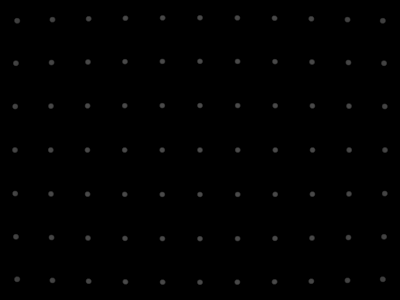

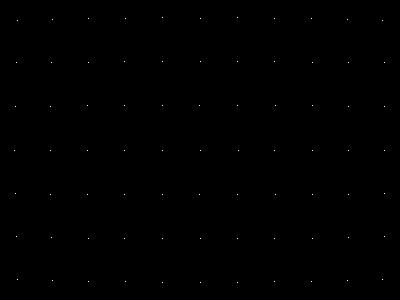

In [22]:
import numpy as np
from PIL import Image
from IPython.display import display

input_image_path = "bokehConfig_fl42_as0_run500000.png"
output_centers_path = "bokehConfig_fl42_as0_run500000_centers.png"
intensity_threshold = 5
min_blob_size = 5

# load and display image
image = np.array(Image.open(input_image_path).convert("L"))
height, width = image.shape
display(Image.fromarray(image))

# find bright bokeh shapes
bright_pixels = image >= intensity_threshold
visited = np.zeros((height, width), bool)
centers_output = np.zeros((height, width), np.uint8)
bokeh_centers = []
neighbors = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]

# extract center of each bright bokeh shape using flood fill
for row in range(height):
    for col in range(width):
        if bright_pixels[row, col] and not visited[row, col]:
            # flood fill to find connected component
            pixels_to_check = [(row, col)]
            visited[row, col] = True
            sum_row = sum_col = pixel_count = 0
            
            while pixels_to_check:
                curr_row, curr_col = pixels_to_check.pop()
                sum_row += curr_row
                sum_col += curr_col
                pixel_count += 1
                
                for dr, dc in neighbors:
                    new_row, new_col = curr_row + dr, curr_col + dc
                    if (0 <= new_row < height and 0 <= new_col < width and 
                        bright_pixels[new_row, new_col] and not visited[new_row, new_col]):
                        visited[new_row, new_col] = True
                        pixels_to_check.append((new_row, new_col))
            
            # if bokeh shape is large enough, record its center
            if pixel_count >= min_blob_size:
                center_row = int(round(sum_row / pixel_count))
                center_col = int(round(sum_col / pixel_count))
                bokeh_centers.append((center_row, center_col))
                centers_output[center_row, center_col] = 255

# ensure image center is included
image_center_row, image_center_col = height // 2, width // 2
min_radius = max(5, int(0.02 * max(height, width)))
center_exists = any((r - image_center_row)**2 + (c - image_center_col)**2 <= min_radius**2 
                   for r, c in bokeh_centers)
if not center_exists:
    bokeh_centers.append((image_center_row, image_center_col))
    centers_output[image_center_row, image_center_col] = 255

Image.fromarray(centers_output).save(output_centers_path)
display(Image.fromarray(centers_output))

## Associating center with PSF
- PSF == bokeh shape
- turns out: center of bokeh matches center of other aperture shapes at same focal length -> not necessary to differentiate later

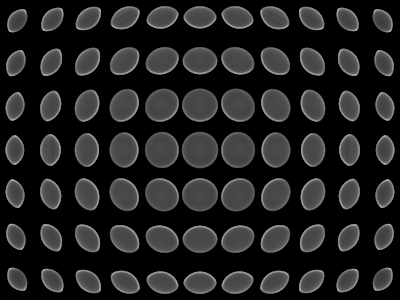

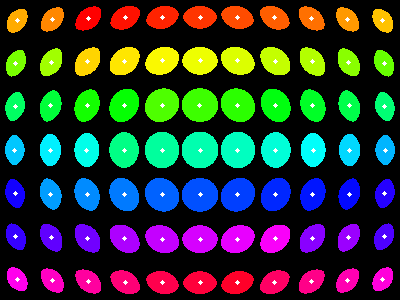

In [23]:
import numpy as np
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt

bokeh_image_path = "bokehConfig_fl42_as6_run500000.png"
intensity_threshold = 30
min_blob_size = 5

# load image
arr2 = np.array(Image.open(bokeh_image_path).convert("L"))
height, width = arr2.shape
display(Image.fromarray(arr2))

# find bokeh shapes
bright_pixels = arr2 >= intensity_threshold
visited = np.zeros((height, width), bool)
lab = -np.ones((height, width), np.int32)
centroids = []
neighbors = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]

# label each bokeh shape using flood fill
label_id = 0
for row in range(height):
    for col in range(width):
        if bright_pixels[row, col] and not visited[row, col]:
            pixels_to_check = [(row, col)]
            visited[row, col] = True
            sum_row = sum_col = pixel_count = 0
            
            while pixels_to_check:
                curr_row, curr_col = pixels_to_check.pop()
                lab[curr_row, curr_col] = label_id
                sum_row += curr_row
                sum_col += curr_col
                pixel_count += 1
                
                for dr, dc in neighbors:
                    new_row, new_col = curr_row + dr, curr_col + dc
                    if (0 <= new_row < height and 0 <= new_col < width and 
                        bright_pixels[new_row, new_col] and not visited[new_row, new_col]):
                        visited[new_row, new_col] = True
                        pixels_to_check.append((new_row, new_col))
            
            if pixel_count >= min_blob_size:
                center_row = sum_row / pixel_count
                center_col = sum_col / pixel_count
                centroids.append((center_row, center_col))
                label_id += 1

# color labels and mark centers
label_vis = np.zeros((height, width, 3), dtype=np.uint8)
cmap = plt.get_cmap('hsv')
for i in range(len(centroids)):
    color = np.array(cmap(i / max(len(centroids), 1))[:3]) * 255
    label_vis[lab == i] = color.astype(np.uint8)
    
    # mark center
    center_r, center_c = centroids[i]
    r, c = int(round(center_r)), int(round(center_c))
    for dr in range(-2, 3):
        for dc in range(-2, 3):
            if dr*dr + dc*dc <= 4:
                nr, nc = r + dr, c + dc
                if 0 <= nr < height and 0 <= nc < width:
                    label_vis[nr, nc] = [255, 255, 255]

display(Image.fromarray(label_vis))

# Playing around with Zernike polynomials
- https://github.com/jacopoantonello/zernike

In [24]:
!pip install zernike 
# https://pypi.org/project/zernike/

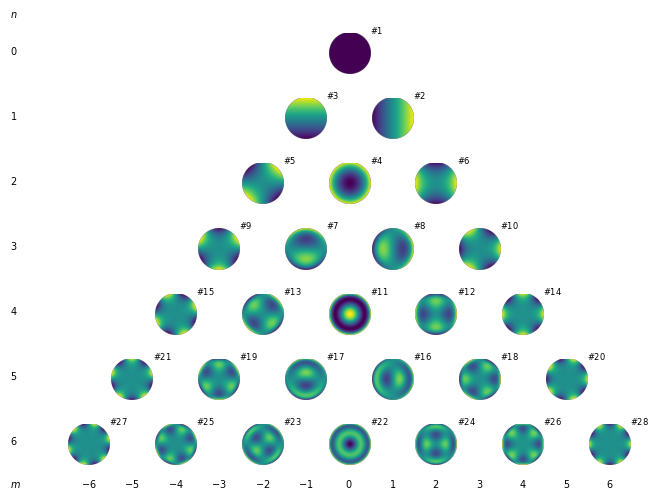

In [25]:
import matplotlib.pyplot as plt
import numpy as np

from zernike import RZern

plt.close('all')

fs = 7
fs1 = 6

nradial = 6
cart = RZern(nradial)
L, K = 300, 300
ddx = np.linspace(-1.0, 1.0, K)
ddy = np.linspace(-1.0, 1.0, L)
xv, yv = np.meshgrid(ddx, ddy)
cart.make_cart_grid(xv, yv)
c = np.zeros(cart.nk)
ns = np.unique(cart.ntab)

fig = plt.figure(1)

span = 0.05
leftoff = .03
while nradial >= 0:
    nk = (nradial + 1) * (nradial + 2) // 2
    nrows = nradial + 1
    ncols = np.where(cart.ntab == nradial)[0].size
    height1 = (1 - (nrows + 1) * span) / nrows
    width1 = (1 - (ncols + 1) * span) / ncols
    min1 = min(width1, height1)
    if min1 > 0:
        height1 = min1
        width1 = min1
        width_span = (1 - min1 * ncols) / (ncols + 1)
        height_span = (1 - min1 * nrows) / (nrows + 1)
        break
    else:
        nradial -= 1

for i in range(nradial + 1):
    n = ns[i]
    inds = np.where(cart.ntab == n)[0]
    ms = cart.mtab[inds]
    inds = inds[ms.argsort()]

    left = (1 - inds.size * width1 - (inds.size - 1) * width_span) / 2
    bott = (1 - nrows * height1 - (nrows - 1) * height_span) / 2

    bt = (bott + (nrows - i - 1) * (height1 + height_span))

    for j in range(inds.size):
        lf = left + j * (width1 + width_span) + leftoff
        ax = fig.add_axes([lf, bt, width1, height1])

        c *= 0.0
        c[inds[j]] = 1.0
        Phi = cart.eval_grid(c, matrix=True)
        ax.imshow(Phi, origin='lower', extent=[0, 1, 0, 1])
        ax.axis('off')

        ze = inds[j] + 1
        zn = cart.ntab[inds[j]]
        zm = cart.mtab[inds[j]]

        ax.text(1,
                1,
                '$\\#' + str(ze) + '$',
                transform=ax.transAxes,
                fontsize=fs1)

    plt.text(0,
             bt + height1 / 2,
             '$' + str(zn) + '$',
             transform=fig.transFigure,
             fontsize=fs)

plt.text(0, 1, '$n$', transform=fig.transFigure, va='top', fontsize=fs)
plt.text(0, 0, '$m$', transform=fig.transFigure, va='bottom', fontsize=fs)

ms = np.arange(-nradial, nradial + 1)
left = (1 - inds.size * width1 - (inds.size - 1) * width_span) / 2
left += leftoff + width1 / 2
for i in range(2 * ncols - 1):
    plt.text(left,
             0,
             '$' + str(ms[i]) + '$',
             transform=fig.transFigure,
             ha='center',
             va='bottom',
             fontsize=fs)
    left += (width1 + width_span) / 2

plt.show()

### Example: plot the first 9 Zernike polynomials

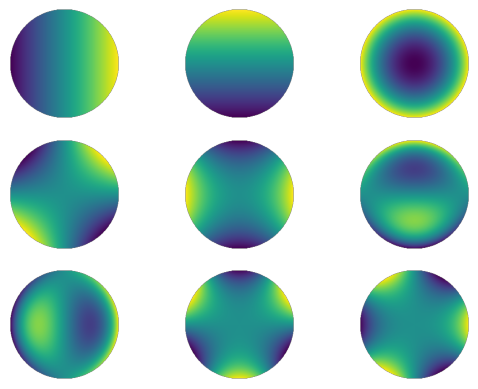

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from zernike import RZern

cart = RZern(6)
L, K = 200, 250
ddx = np.linspace(-1.0, 1.0, K)
ddy = np.linspace(-1.0, 1.0, L)
xv, yv = np.meshgrid(ddx, ddy)
cart.make_cart_grid(xv, yv)

c = np.zeros(cart.nk)
plt.figure(1)
for i in range(1, 10):
    plt.subplot(3, 3, i)
    c *= 0.0
    c[i] = 1.0
    Phi = cart.eval_grid(c, matrix=True)
    plt.imshow(Phi, origin='lower', extent=(-1, 1, -1, 1))
    plt.axis('off')

plt.show()

### Example: fit Zernike polynomials in Cartesian coordinates

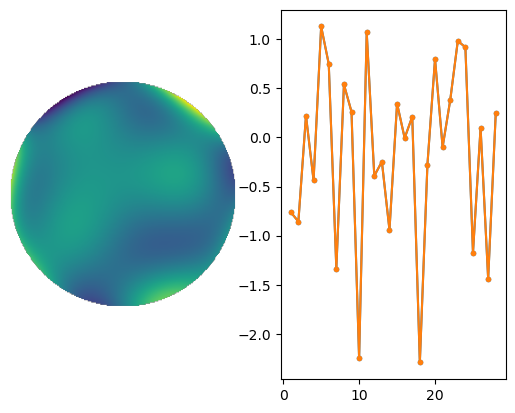

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from zernike import RZern

cart = RZern(6)
L, K = 200, 250
ddx = np.linspace(-1.0, 1.0, K)
ddy = np.linspace(-1.0, 1.0, L)
xv, yv = np.meshgrid(ddx, ddy)
cart.make_cart_grid(xv, yv)

c0 = np.random.normal(size=cart.nk)
Phi = cart.eval_grid(c0, matrix=True)
c1 = cart.fit_cart_grid(Phi)[0]
plt.figure(1)
plt.subplot(1, 2, 1)
plt.imshow(Phi, origin='lower', extent=(-1, 1, -1, 1))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.plot(range(1, cart.nk + 1), c0, marker='.')
plt.plot(range(1, cart.nk + 1), c1, marker='.')

plt.show()

### Example: fit Zernike polynomials in polar coordinates

In [28]:
import numpy as np
from zernike import RZern, FitZern

pol = RZern(6)
L, K = 200, 250
ip = FitZern(pol, L, K)

pol.make_pol_grid(ip.rho_j, ip.theta_i)
c_true = np.random.normal(size=pol.nk)
Phi = pol.eval_grid(c_true)
c_hat = ip.fit(Phi)
R = np.zeros((pol.nk, 3))
R[:, 0] = c_true
R[:, 1] = c_hat
R[:, 2] = np.abs(c_true - c_hat)
print(R)
np.linalg.norm(c_true - c_hat)/np.linalg.norm(c_true)

[[ 1.45021823e+00  1.45023526e+00  1.70300942e-05]
 [ 5.73820735e-01  5.73776905e-01  4.38301079e-05]
 [-5.78595845e-01 -5.78565075e-01  3.07692092e-05]
 [-6.89211967e-01 -6.89229166e-01  1.71991304e-05]
 [-1.60035835e+00 -1.60010131e+00  2.57043321e-04]
 [-1.98421203e-01 -1.98400796e-01  2.04066506e-05]
 [-5.02601385e-01 -5.02570320e-01  3.10657693e-05]
 [-1.81925289e+00 -1.81915497e+00  9.79163388e-05]
 [-2.02852917e+00 -2.02776690e+00  7.62262770e-04]
 [-9.10574180e-01 -9.10226369e-01  3.47811000e-04]
 [ 1.15746113e+00  1.15743067e+00  3.04611113e-05]
 [-6.65472371e-01 -6.65352599e-01  1.19772237e-04]
 [-1.83552545e-02 -1.83507542e-02  4.50029780e-06]
 [-6.01458144e-01 -6.01052759e-01  4.05384826e-04]
 [-8.91774045e-01 -8.91186696e-01  5.87348827e-04]
 [-7.12382648e-01 -7.12324060e-01  5.85872869e-05]
 [ 5.50336981e-01  5.50291719e-01  4.52617673e-05]
 [ 1.15916615e+00  1.15871607e+00  4.50081396e-04]
 [ 1.02176924e+00  1.02137745e+00  3.91795567e-04]
 [ 1.00078603e-02  9.99755808e-

np.float64(0.0005907013829775302)

# Fit Zernike to Bokeh

### Crop bokeh shape

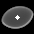

In [33]:
import numpy as np
from PIL import Image
from IPython.display import display

# bokeh cropping
center_index = 2

# find bokeh pixels
rows, cols = np.where(lab == center_index)
weights = arr2[rows, cols].astype(np.float32)

# intensity-weighted center
center_r = np.average(rows, weights=weights)
center_c = np.average(cols, weights=weights)

# find max distance from weighted center
distances = np.sqrt((rows - center_r)**2 + (cols - center_c)**2)
radius = int(np.ceil(distances.max()))

# crop square region around center
r0 = int(center_r - radius)
r1 = int(center_r + radius)
c0 = int(center_c - radius)
c1 = int(center_c + radius)

crop_img = arr2[r0:r1, c0:c1]

# save crop
Image.fromarray(crop_img).save("bokeh_crop.png")

# helper: save ASCII PGM (P2)
def save_pgm_ascii(path, img_uint8):
    h, w = img_uint8.shape
    with open(path, 'w', newline='\n') as f:
        f.write(f"P2\n{w} {h}\n255\n")
        for row in img_uint8:
            f.write(' '.join(str(int(v)) for v in row) + '\n')

# save inverted pgm 512x512 as ASCII (P2)
inv512 = 255 - np.array(Image.fromarray(crop_img).resize((512, 512), Image.BILINEAR))
save_pgm_ascii("bokeh_crop_inverted.pgm", inv512.astype(np.uint8))

# mark center on crop for visualization
crop_vis = np.stack([crop_img] * 3, axis=-1)
center_in_crop_r = int(center_r - r0)
center_in_crop_c = int(center_c - c0)
for dr in range(-2, 3):
    for dc in range(-2, 3):
        if dr*dr + dc*dc <= 4:
            nr, nc = center_in_crop_r + dr, center_in_crop_c + dc
            if 0 <= nr < crop_img.shape[0] and 0 <= nc < crop_img.shape[1]:
                crop_vis[nr, nc] = [255, 255, 255]

display(Image.fromarray(crop_vis))

### Fit Zernike polynomial

Note: The PGM is now saved in ASCII (P2) format instead of binary (P5). This is larger on disk but human-readable and compatible with most PGM readers.

coeff: [  0.42628778   4.20912133   7.3395501   -0.05217333 -40.31244927
  -2.78330529  10.0789678    5.74536864  31.02470623 -11.30071771]


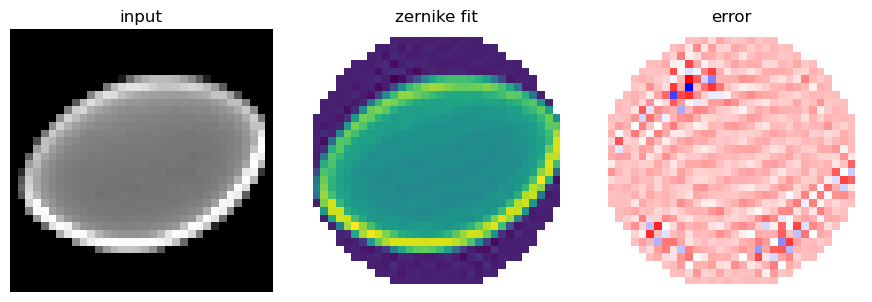

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from zernike import RZern

# normalize bokeh
crop = crop_img.astype(np.float32)
m = crop.max()
if m:
    crop /= m

# center on square canvas
h, w = crop.shape
cr = int(round(center_r - r0))
cc = int(round(center_c - c0))
rad = int(np.ceil(max(cr, h - cr, cc, w - cc)))
N = max(2 * rad, 1)
can = np.zeros((N, N), np.float32)
offr = N // 2 - cr
offc = N // 2 - cc
dr0, dc0 = max(offr, 0), max(offc, 0)
dr1, dc1 = min(offr + h, N), min(offc + w, N)
sr0, sc0 = max(-offr, 0), max(-offc, 0)
sr1, sc1 = sr0 + (dr1 - dr0), sc0 + (dc1 - dc0)
can[dr0:dr1, dc0:dc1] = crop[sr0:sr1, sc0:sc1]

# fit zernike
x = np.linspace(-1.0, 1.0, N)
xv, yv = np.meshgrid(x, x)
phi = can * ((xv * xv + yv * yv) <= 1.0)
cart = RZern(30)
cart.make_cart_grid(xv, yv)
coef = cart.fit_cart_grid(phi)[0]
recon = cart.eval_grid(coef, matrix=True)
print("coeff:", coef[:10])

# viz
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
axs[0].imshow(phi, cmap='gray', extent=(-1, 1, -1, 1))
axs[0].set_title('input')
axs[0].axis('off')
axs[1].imshow(recon, extent=(-1, 1, -1, 1))
axs[1].set_title('zernike fit')
axs[1].axis('off')
axs[2].imshow(phi - recon, cmap='bwr', extent=(-1, 1, -1, 1))
axs[2].set_title('error')
axs[2].axis('off')
plt.tight_layout()
plt.show()

### Random samples on a unit disk

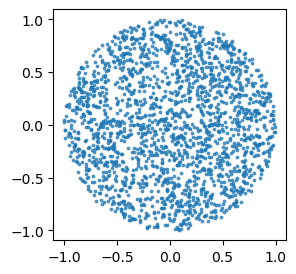

In [31]:
import numpy as np
import matplotlib.pyplot as plt

n = 2000
u = np.random.rand(n)
v = np.random.rand(n)
r = np.sqrt(u)
theta = 2 * np.pi * v
x = r * np.cos(theta)
y = r * np.sin(theta)

plt.figure(figsize=(3, 3))
plt.scatter(x, y, s=3, alpha=0.7)
plt.show()